#BadHonnef2025: Retrievals using petitRADTRANS - Introduction
**Text fett markieren**
## Authors: Paul Molliere, K. Angelique Kahle; (Max Planck Institute for Astronomy)

Based on Sagan Summer School 2023 materials

## Google Colab Usage

*Please read (don't just hit run) the information given above each code cell as there are separate install cells for Colab*
&#128992;
*and running Python on your computer*
&#128309;.

**Confirm login account**
* Please make sure to be logged in with the Google account you want to use for the exercises before running the code cells below. You can check by clicking the circular account icon in the top right corner of the colab notebook.

**Working directory**
* Note: The software and data will be installed in a directory called "SSW2023/pRT" in your Google drive. This directory will be created if it does not exist.

**Running cells**
* Run cells individually by clicking on the triangle on each cell

**To Restart runtime**
*   Click on Runtime menu item
*   Select Restart runtime
*   Select Run code cells individually from the top

**To Recreate runtime**
*   Click on Runtime menu item
*   Select Disconnect and Delete runtime
*   Select Run code cells individually from the top

**To Exit:**
*   Close the browser window

# &#128992; When running on Colab: pRT installation and setup
This cell installs everything you need in Colab, as explained in the hands-on session's setup documentation.

&#128992; **Run this cell if you are running on Colab**

In [ ]:
import os
os.chdir('/content/')
!rm -rf multinest
!git clone https://www.github.com/johannesbuchner/multinest.git
!cd multinest/build && cmake ..
!sed -i 's/-lmkl_gf_lp64 -lmkl_gnu_thread/-lmkl_mc3 -lmkl_rt -lmkl_avx2/' multinest/build/src/CMakeFiles/multinest_shared.dir/link.txt
!cd multinest/build && make && make install
!cp /content/multinest/lib/* /lib/

!pip install numpy meson-python ninja
import numpy as np
!pip install "petitRADTRANS[retrieval]==3.1.0" --no-build-isolation

Cloning into 'multinest'...
remote: Enumerating objects: 549, done.
remote: Counting objects: 100% (118/118), done.
remote: Compressing objects: 100% (98/98), done.
remote: Total 549 (delta 65), reused 49 (delta 19), pack-reused 431 (from 1)
Receiving objects: 100% (549/549), 300.02 KiB | 2.52 MiB/s, done.
Resolving deltas: 100% (342/342), done.
CMake Deprecation Warning at CMakeLists.txt:1 (cmake_minimum_required):
  Compatibility with CMake < 3.10 will be removed from a future version of
  CMake.

  Update the VERSION argument <min> value.  Or, use the <min>...<max> syntax
  to tell CMake that the project requires at least <min> but has been updated
  to work with policies introduced by <max> or earlier.


-- The Fortran compiler identification is GNU 11.4.0
-- The C compiler identification is GNU 11.4.0
-- The CXX compiler identification is GNU 11.4.0
-- Detecting Fortran compiler ABI info
-- Detecting Fortran compiler ABI info - done
-- Check for working Fortran compiler: /usr/bin/

&#128992; **Run the  2 cells if you are running on Colab**

This cell mounts the Google Drive (please allow it to do so) and specifies the path of the pRT input data folder. If you *are* running on Colab, but changed the default path specified in the setup notebook, please modify the path to correctly point to the input data in your Google Drive.

"BadHonnef2025/pRT" is the default and you can leave that as-is or change it in the fill in box on the right. Be sure to pick a directory name that does not have any spaces. *This must match the directory used in the setup notebook.* This cell must be run to define the data location.

In [ ]:
# If you update the directory in the box on the right, re-run this cell
pRT_dir = 'BadHonnef2025/pRT' #@param {type:"string"}

In [ ]:
from google.colab import drive
import os

drive.mount("/content/drive")

# Google top level drive dir
drive_dir = "/content/drive/MyDrive/"

# pRT directory path
pRT_path = os.path.join(drive_dir, pRT_dir)

# Create the pRT directory
try:
    os.makedirs(pRT_path, exist_ok = True)
    print("Directory '%s' created successfully" %pRT_path)
except OSError as error:
    print("Directory '%s' can not be created")

# Change to the pRT_path
os.chdir(pRT_path)

#set input data path
from petitRADTRANS.config import petitradtrans_config_parser
petitradtrans_config_parser.set_input_data_path(r'/content/drive/MyDrive/BadHonnef2025/pRT/input_data_BH/input_data')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Directory '/content/drive/MyDrive/BadHonnef2025/pRT' created successfully
Input data path changed to '/content/drive/MyDrive/BadHonnef2025/pRT/input_data_BH/input_data'


# &#128309; When running on your computer:
Please modify `/path/of/your/choice/` below to point to the `input_data_BH` folder you downloaded as described in the setup notebook. Then run the cell below to set the `pRT_input_data_path` environment variable accordingly. This is done such that pRT knows where the input data is.
Also, make sure you are running this notebook within the environment where you previously installed pRT.

&#128309; **Run this cell if running on your computer (not Colab!)**

In [ ]:
import os
from petitRADTRANS.config import petitradtrans_config_parser

petitradtrans_config_parser.set_input_data_path(r'/path/of/your/choice/input_data_BH/input_data')

Input data path changed to '/path/of/your/choice/input_data_BH/input_data'


# petitRADTRANS: introduction exercises
## Defining an atmosphere and calculating its emission spectrum
To get started, let's calculate the emission spectrum of a hot Jupiter. The detailed description of everything that pRT allows you to do can be found in the [online tutorial](https://petitradtrans.readthedocs.io/en/latest/content/tutorial.html). Because we don't have too much time, we will only discuss a subset of this here.

We start by making a pRT object, which we call `atmosphere` here; we tell it which opacity species to use, and over which wavelength range. More information on which opacity species are available can be found [here](https://petitradtrans.readthedocs.io/en/latest/content/available_opacities.html). Flags like `__POKAZATEL` reference a specific opacity data base, `.R400` means that the opacity resolution ($\lambda / \Delta \lambda$) is equal to 400 in our example. [pRT allows users to bin down line opacities to any resolution](https://petitradtrans.readthedocs.io/en/latest/content/notebooks/rebinning_opacities.html), on the fly.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize'] = (10, 6)

from petitRADTRANS.radtrans import Radtrans
import petitRADTRANS.physical_constants as cst

atmosphere = Radtrans(
                        pressures=np.logspace(-6, 2, 100), # pressure layers in the atmosphere.
                                                           # Should be log-spaced, and ordered in increasing pressure
                                                           # Here we go from 10**-6 to 100 bar.
                        line_species=[ # Line absorbers:
                            'H2O__POKAZATEL.R200', # __POKAZATEL stands for the POKAZATEL water line list from Exomol.
                            'CO-NatAbund__HITEMP.R200', # .R200 means that the opacity resolution is 200.
                            'CH4__HITEMP.R200',
                            'CO2.R200', # We have just one source for CO2 opacities in our database,
                                        # so no special __selection is required.
                            'SO2.R200',
                            'Na__Allard.R200',
                            'K__Allard.R200'],
                        rayleigh_species=['H2', 'He'], # Rayleigh scatterers
                        gas_continuum_contributors=['H2-H2', 'H2-He'], # Collision-induced absorption opacity
                        wavelength_boundaries=[0.3, 15]
)

Loading Radtrans opacities...
 Loading line opacities of species 'H2O__POKAZATEL.R200' from file '/content/drive/MyDrive/BadHonnef2025/pRT/input_data_BH/input_data/opacities/lines/correlated_k/H2O/1H2-16O/1H2-16O__POKAZATEL.R200_0.3-50mu.ktable.petitRADTRANS.h5'... Done.
 Loading line opacities of species 'CO-NatAbund__HITEMP.R200' from file '/content/drive/MyDrive/BadHonnef2025/pRT/input_data_BH/input_data/opacities/lines/correlated_k/CO/C-O-NatAbund/C-O-NatAbund__HITEMP.R200_0.1-250mu.ktable.petitRADTRANS.h5'... Done.
 Loading line opacities of species 'CH4__HITEMP.R200' from file '/content/drive/MyDrive/BadHonnef2025/pRT/input_data_BH/input_data/opacities/lines/correlated_k/CH4/12C-1H4/12C-1H4__HITEMP.R200_0.1-250mu.ktable.petitRADTRANS.h5'... Done.
 Loading line opacities of species 'CO2.R200' from file '/content/drive/MyDrive/BadHonnef2025/pRT/input_data_BH/input_data/opacities/lines/correlated_k/CO2/12C-16O2/12C-16O2__UCL-4000.R200_0.3-50mu.ktable.petitRADTRANS.h5'... Done.
 Load

/usr/local/lib/python3.11/dist-packages/petitRADTRANS/radtrans.py:957: FutureWarning: usage of CIA aliases is deprecated and will be removed in a future update.
Use the CIA actual name, with pRT's CIA separator ('--') between colliding species, instead
  warnings.warn(


 Loading CIA opacities for H2-H2 from file '/content/drive/MyDrive/BadHonnef2025/pRT/input_data_BH/input_data/opacities/continuum/collision_induced_absorptions/H2--H2/H2--H2-NatAbund/H2--H2-NatAbund__BoRi.R831_0.6-250mu.ciatable.petitRADTRANS.h5'... Done.
 Loading CIA opacities for H2-He from file '/content/drive/MyDrive/BadHonnef2025/pRT/input_data_BH/input_data/opacities/continuum/collision_induced_absorptions/H2--He/H2--He-NatAbund/H2--He-NatAbund__BoRi.DeltaWavenumber2_0.5-500mu.ciatable.petitRADTRANS.h5'... Done.
 Successfully loaded all CIA opacities
Successfully loaded all opacities


Next we define the atmospheric temperature structure, using a [Guillot (2010)](https://ui.adsabs.harvard.edu/abs/2010A%26A...520A..27G/abstract) temperature profile. It has the following free parameters:
- $\kappa_{\rm IR}$ is the average infrared opacity (so photon absorption cross-section per unit mass of atmospheric material).
- $\gamma$ is the ratio between the optical and infrared opacity and controls whether temperature inversions form in the atmosphere.
- $T_{\rm int}$ is the internal temperature of the planet, defined such that the net planet flux radiated to space at the top of the atmosphere is $F_{\rm int}=\sigma T_{\rm int}^4$, where $\sigma$ is the Stefan-Boltzmann constant.
- $T_{\rm equ}$ is the equilibrium temperature of the planet, expressing the strength of irradiation, defined such that the planet-wide average (over the full sphere) of the stellar flux received at the location of the planet is $F_{\rm equ}=\sigma T_{\rm equ}^4$. It holds that $T_{\rm eff}^4 = T_{\rm equ}^4 + T_{\rm int}^4$, where $T_{\rm eff}$ is the planet's effective temperature.

The temperature profile is then defined like this:
$$T(\tau)^4 = \frac{3T_{\rm int}^4}{4}\left(\frac{2}{3}+\tau\right) + \frac{3T_{\rm equ}^4}{4}\left[\frac{2}{3}+\frac{1}{\gamma\sqrt{3}}+\left(\frac{\gamma}{\sqrt{3}}-\frac{1}{\gamma\sqrt{3}}\right)e^{-\gamma\tau\sqrt{3}}\right].$$
Here, $\tau$ is the so-called optical depth, which is defined as altitude in units of the mean free path of a photon. $\tau = 0$ denotes the top of the atmosphere and we go deeper (to lower altitudes) into the atmosphere for $\tau > 0$. So, when moving from the top to an altitude corresponding to $\tau=3$, say, a photon would on average be absorbed three times (which makes it unkikely, but not impossible, that a photon travels that far). One can approximate $\tau = P\kappa_{\rm IR}/g$, where $g$ is the gravitational acceleration in the atmosphere and $P$ is the pressure. In this way we can transform from $T(\tau)$ to $T(P)$.

**Please note that the Guillot (2010) formulation is "only" a useful mathematical approximation of how atmospheric temperature structures behave upon variation of fundamental input parameters. It is a useful qualitative tool, but cannot predict atmospheric pressure-temperature structures quantitatively. In general things are more complicated. Atmospheres do not just have one infrared opacity and one $\gamma$ value, instead both vary as function of wavelength and altitude. In addition, Guillot (2010) assumes that the atmosphere is 1-d, that all energy is transported by radiation, etc.** The Guillot formulation may still be a useful function to parameterize the shape of atmospheric temperature structures in a retrieval, however. In this case the best-fit parameters would not tell you anything about the true values of $\kappa_{\rm IR}$, $\gamma$, etc., since a retrieval does not know anything about the physical interpretation we associate with parameters. In this case the Guillot parameters are merely a knob to tune the temperature profile to the right shape.

In [ ]:
from petitRADTRANS.physics import temperature_profile_function_guillot_global

# All I/O in petitRADTRANS in in cgs units, except for pressure (which is in bars).
# Internally, pRT does everything in cgs units (so pressure and mean molar mass are converted to cgs internally).

pressures_bar = atmosphere.pressures * 1e-6 # cgs to bar since pressures are in cgs units inside pRT.

gravity = 10**3.5 # Typical hot Jupiter gravity value

infrared_mean_opacity = 0.01 # This is kappa_iR, and we take a ~typical hot Jupiter opacity value here.
gamma = 0.4 # This gamma leads to a non-inverted atmosphere.
intrinsic_temperature = 200. # Intrinsic temperature T_int, set by the cooling rate of the planet.
equilibrium_temperature = 1500. # Euqilibrium temperature T_equ, set by the irradiation strength of the star.

temperatures = temperature_profile_function_guillot_global(
    pressures=pressures_bar,
    infrared_mean_opacity=infrared_mean_opacity,
    gamma=gamma,
    gravities=gravity,
    intrinsic_temperature=intrinsic_temperature,
    equilibrium_temperature=equilibrium_temperature
)

This is what it looks like:

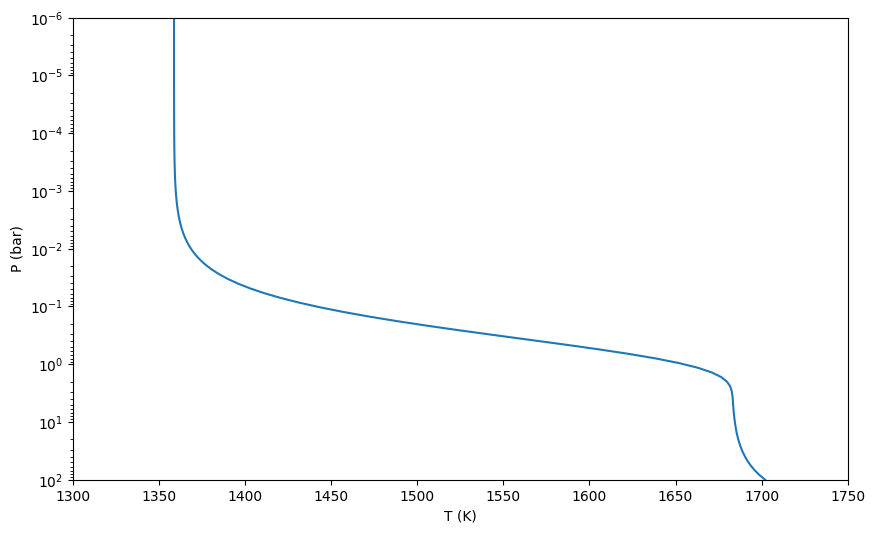

In [ ]:
plt.plot(temperatures, pressures_bar)
plt.yscale('log')
plt.xlim([1300, 1750])
plt.ylim([1e2, 1e-6])
plt.xlabel('T (K)')
plt.ylabel('P (bar)')
plt.show()

### Exercise 1:
Currently $\gamma=0.4$, so the optical opacity absorbing the stellar light is smaller than the infrared opacity. By filling in the blanks below, Change $\gamma$ to 2.5 and save the resulting temperature structure in an array called `inverted_temperature`. Plot `temperature` and `inverted_temperature`. How do they compare? What do you think is happening? [You can click here to see if your solution is correct](https://www2.mpia-hd.mpg.de/~molliere/SSW/solutions_notebook_1.html#Exercise-1:).

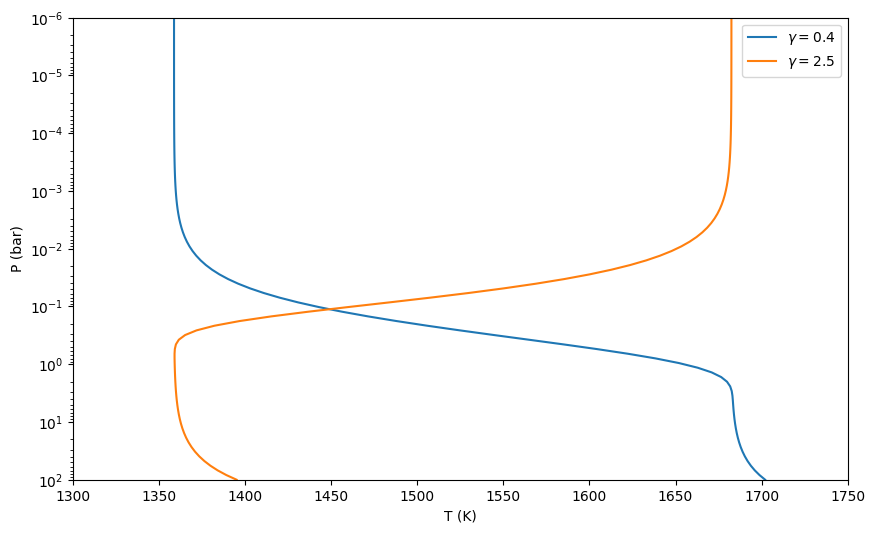

In [ ]:
gamma = 2.5 # ... # Fill in
inverted_temperatures = temperature_profile_function_guillot_global(
    pressures=pressures_bar,
    infrared_mean_opacity=infrared_mean_opacity,
    gamma=gamma,
    gravities=gravity,
    intrinsic_temperature=intrinsic_temperature,
    equilibrium_temperature=equilibrium_temperature
) # ... # Fill in

plt.plot(temperatures, pressures_bar, label = '$\gamma = 0.4$')
plt.plot(inverted_temperatures, pressures_bar, label = '$\gamma = 2.5$')
plt.yscale('log')
plt.xlim([1300, 1750])
plt.ylim([1e2, 1e-6])
plt.xlabel('T (K)')
plt.ylabel('P (bar)')
plt.legend()
plt.show()

Now we define the atmospheric composition by providing mass fractions of absorbing species in every layer. We multiply the values by `np.ones_like(temperatures)`, because they are defined layer-by-layer; here we chose a vertically constant prescription. But you can also use [chemical equilibrium abundances in pRT](https://petitradtrans.readthedocs.io/en/latest/content/notebooks/interpolating_chemical_equilibrium_abundances.html), for example.

In [ ]:
mass_fractions = {}
# Typical values for H2/He dominated atmospheres
mass_fractions['H2'] = 0.74 * np.ones_like(temperatures)
mass_fractions['He'] = 0.24 * np.ones_like(temperatures)
mass_fractions['H2O__POKAZATEL.R200'] = 0.001 * np.ones_like(temperatures)
mass_fractions['CO-NatAbund__HITEMP.R200'] = 0.005 * np.ones_like(temperatures)
mass_fractions['CO2.R200'] = 0.00001 * np.ones_like(temperatures)
mass_fractions['SO2.R200'] = 0.00001 * np.ones_like(temperatures)
mass_fractions['CH4__HITEMP.R200'] = 0.000001 * np.ones_like(temperatures)
mass_fractions['Na__Allard.R200'] = 1e-5 * np.ones_like(temperatures)
mass_fractions['K__Allard.R200'] = 1e-6 * np.ones_like(temperatures)

# Mean molar mass
mean_molar_masses = 2.33 * np.ones_like(temperatures) # 2.3 is the typical value for a H2/He dominated atmosphere

If we wanted to be fully correct, we'd make sure that the mass fractions sum up to 1 in every layer. This is especially important if we want to calculate the mean molar masses from the atmospheric composition. In fact we will enforce this in the retrievals studied in the second notebook. Since we provide a mean molar mass explictly here, and want to simply study what a typical hot Jupiter spectrum looks like, it is enough to just specify order-of-magnitude correct values for all atmospheric absorbers.

Finally, **let's calculate the flux emitted by the exoplanet atmosphere!**

In [ ]:
frequencies, flux, _ = atmosphere.calculate_flux(
    temperatures=temperatures,
    mass_fractions=mass_fractions,
    mean_molar_masses=mean_molar_masses,
    reference_gravity=gravity,
    frequencies_to_wavelengths=False
)
wavelengths = cst.c/frequencies

And now we plot it. Note the use of `cst.c` to convert from frequency to wavelength. `cst.c` is the speed of light in cm/s as defined in pRT's `physical_constants` module. It is imported like this: `import petitRADTRANS.physical_constants as cst`. See [here](https://petitradtrans.readthedocs.io/en/latest/autoapi/petitRADTRANS/physical_constants/index.html) for a list of all pre-defined natural constants (all are defined in cgs units). **If we had set `frequencies_to_wavelengths=True` (which is the keyword's default value), pRT would have returned wavelengths (not frequencies) and flux in $F_{\lambda}$, not $F_\nu$. We need $F_\nu$ below, however, becaues pRT stores stellar fluxes also as $F_\nu$.**

Text(0, 0.5, 'Planet flux, $F_{\\nu}$ [erg cm$^{-2}$ s$^{-1}$ Hz$^{-1}$]')

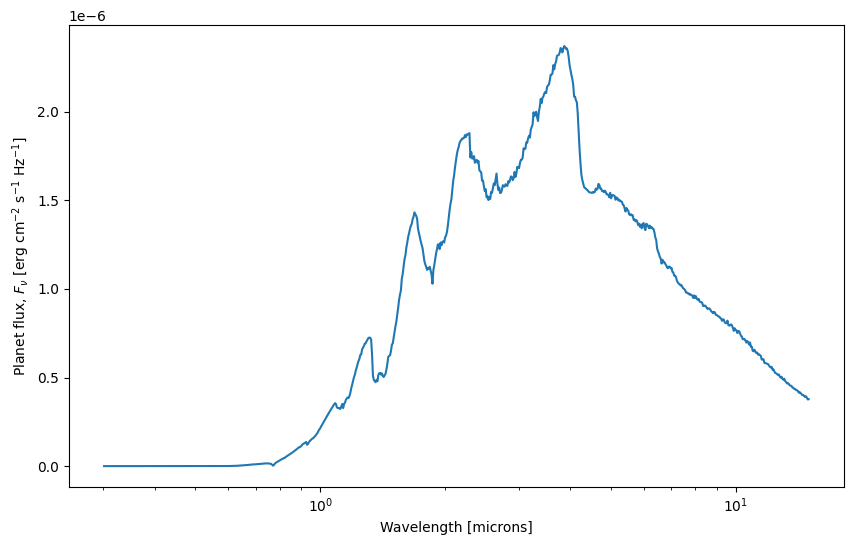

In [ ]:
plt.plot(wavelengths*1e4, flux)

plt.xscale('log')
plt.xlabel('Wavelength [microns]')
plt.ylabel(r'Planet flux, $F_{\nu}$ [erg cm$^{-2}$ s$^{-1}$ Hz$^{-1}$]')

### Exercise 2:
Filling in the blanks, repeat the flux caclulation using the inverted temperature structure from above (`inverted_temperatures`). Show both fluxes in one plot. What can you see? Why does this happen? [You can click here to see if your solution is correct](https://www2.mpia-hd.mpg.de/~molliere/SSW/solutions_notebook_1.html#Exercise-2:).

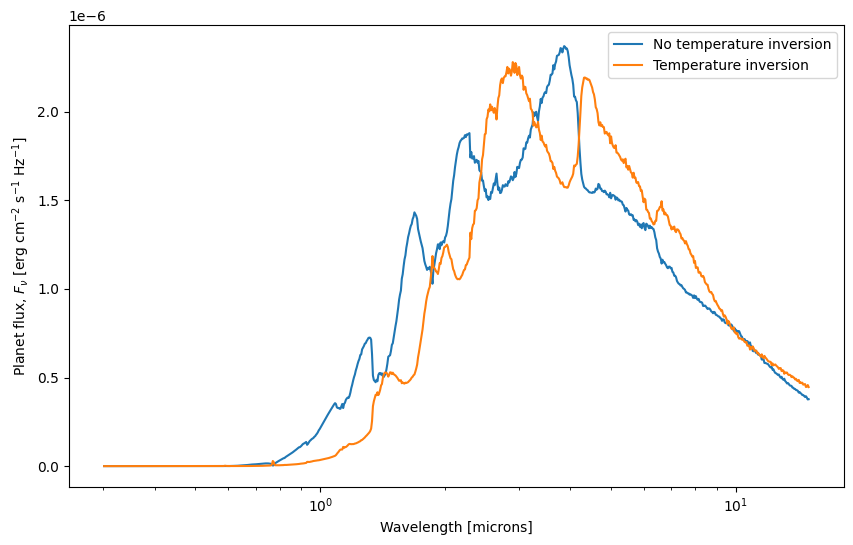

In [ ]:
flux_non_inverted = flux

frequencies, flux_inverted, _ = atmosphere.calculate_flux(
    temperatures=inverted_temperatures,
    mass_fractions=mass_fractions,
    mean_molar_masses=mean_molar_masses,
    reference_gravity=gravity,
    frequencies_to_wavelengths=False
) # wavelengths, flux_inverted, _ = atmosphere.calculate_flux(... # Fill in!

plt.plot(wavelengths*1e4, flux, label = 'No temperature inversion')
plt.plot(wavelengths*1e4, flux_inverted, label = 'Temperature inversion')

plt.xscale('log')
plt.xlabel('Wavelength [microns]')
plt.ylabel(r'Planet flux, $F_{\nu}$ [erg cm$^{-2}$ s$^{-1}$ Hz$^{-1}$]')
plt.legend()

### Exercise 3:
By filling in the blanks, set up the atmosphere to be isothermal, at 1500 K (so replace the temperature array in `calculate_flux()` with an array containing only the value `1500.`). Compare the resulting spectrum with the inverted and non-inverted emission spectra from above. What do you observe, and why? [You can click here to see if your solution is correct](https://www2.mpia-hd.mpg.de/~molliere/SSW/solutions_notebook_1.html#Exercise-3:).

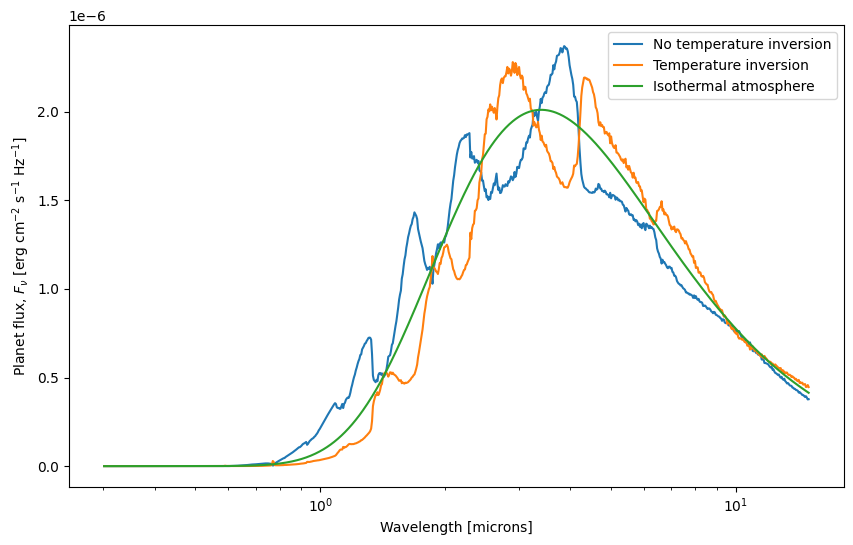

In [ ]:
frequencies, flux_isothermal, _ = atmosphere.calculate_flux(
    temperatures=np.ones_like(temperatures)*1500.,
    mass_fractions=mass_fractions,
    mean_molar_masses=mean_molar_masses,
    reference_gravity=gravity,
    frequencies_to_wavelengths=False
) # wavelengths, flux_isothermal, _ = atmosphere.calculate_flux(... # Fill in!


plt.plot(wavelengths*1e4, flux, label = 'No temperature inversion')
plt.plot(wavelengths*1e4, flux_inverted, label = 'Temperature inversion')
plt.plot(wavelengths*1e4, flux_isothermal, label = 'Isothermal atmosphere')


plt.xscale('log')
plt.xlabel('Wavelength [microns]')
plt.ylabel(r'Planet flux, $F_{\nu}$ [erg cm$^{-2}$ s$^{-1}$ Hz$^{-1}$]')
plt.legend()

Emission spectra of transiting planets are usually plotted as contrast, which means that the planet flux $F_{\rm P}$ is divided by the stellar flux $F_{\rm *}$. The planetary flux returned by pRT is the emergent flux at the top of the planet's atmosphere. So to get the contrast at the location of the observer we have to calculate the following:
\begin{equation}
C = \left(F_{\rm P} \cdot \frac{4\pi R_{\rm P}^2}{4\pi  d^2}\right) \left(F_{\rm *} \cdot \frac{4\pi  R_{*}^2}{4\pi  d^2}\right)^{-1} = \frac{F_{\rm P}}{F_{\rm *}} \left(\frac{R_{\rm P}}{R_{*}}\right)^2,
\end{equation}
where $d$ is the distance to the observer. **Please note that the contrast is often simply written as $F_{\rm P}/F_{\rm *}$, assuming that "F" means flux measured at the location of the observer, so not at the top of the atmosphere of the planet or star.** [pRT has a library of stellar spectra available](https://petitradtrans.readthedocs.io/en/latest/content/notebooks/utility_functions.html#PHOENIX-and-ATLAS9-stellar-model-spectra). We can use this function to extract the flux at the same wavelength spacing as the pRT planet emission model:

In [ ]:
from petitRADTRANS.fortran_rebin import fortran_rebin as fr
from petitRADTRANS.stellar_spectra.phoenix import PhoenixStarTable
import petitRADTRANS.physical_constants as cst

star = PhoenixStarTable()

def get_stellar_spectrum(pRT_object, stellar_temperature):

    stellar_spec, __ = star.compute_spectrum(stellar_temperature)

    wlen_in_micron = stellar_spec[:,0]/1e-4
    flux_star = stellar_spec[:,1]

    bins_borders_take_freq = pRT_object._frequency_bins_edges
    bins_borders_take = cst.c/pRT_object._frequency_bins_edges/1e-4

    wavelens = np.array((bins_borders_take_freq[1:]+bins_borders_take_freq[:-1])/2.)
    wavelens = cst.c/wavelens*1e4
    widths = np.diff(bins_borders_take)

    bin_flux = fr.rebin_spectrum_bin(wlen_in_micron,
                                    flux_star,
                                    wavelens,
                                    widths)

    return bin_flux

Now, assuming that the planet has a radius of 1.5 Jupiter radii (we use `1.5*cst.r_jup`) and that the star has a radius of one solar radius (we use `cst.r_sun`) and an effective temperature of 5700 K, we plot the contrast between planet and star in units of parts-per-million (ppm):

Loading PHOENIX star table in file '/content/drive/MyDrive/BadHonnef2025/pRT/input_data_BH/input_data/stellar_spectra/phoenix/phoenix.startable.petitRADTRANS.h5'... Done.


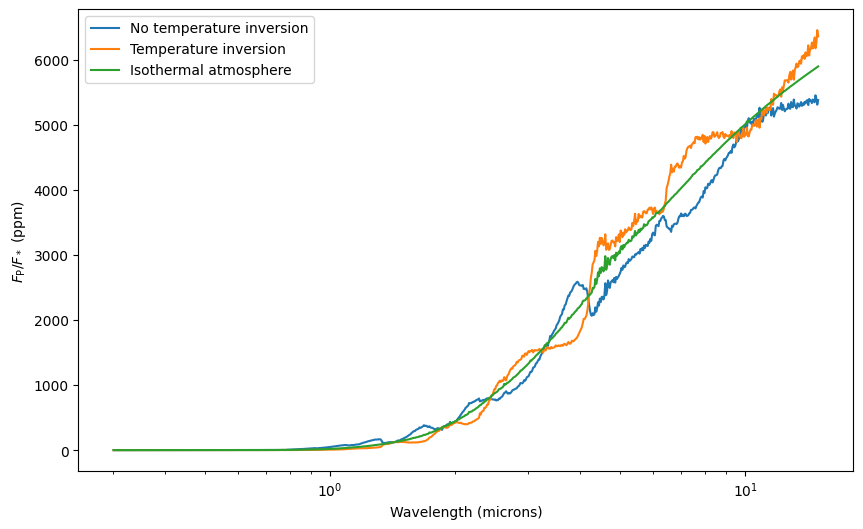

In [ ]:
stellar_flux_at_top_of_atmosphere = get_stellar_spectrum(atmosphere, 5700.)

scaling_factor = (1.5*cst.r_jup)**2./cst.r_sun**2./stellar_flux_at_top_of_atmosphere*1e6

plt.plot(wavelengths*1e4, flux_non_inverted*scaling_factor, label = 'No temperature inversion')
plt.plot(wavelengths*1e4, flux_inverted*scaling_factor, label = 'Temperature inversion')
plt.plot(wavelengths*1e4, flux_isothermal*scaling_factor, label = 'Isothermal atmosphere')

plt.xscale('log')
plt.xlabel('Wavelength (microns)')
plt.ylabel(r'$F_{\rm P}/F_{\rm *}$ (ppm)')
plt.legend()
plt.show()

## Calculating transmission spectra

Above we calculated the emission spectrum of the planet with `calculate_flux()`. The transmission radius of the planet (so the effective size of the planet when occulting the stellar disk) can be calculated via `calculate_transit_radii()`.

The parameteres are similar to those of `calculate_flux()`, but we now additionally need to define a planetary reference radius `planet_radius` and reference pressure `reference_pressure`. This is because the vertical coordinate in pRT is pressure $P$, but we have to determine the planet's radius as a function of pressure, $r(P)$, for the calculation of the transmission spectrum. This is done inside pRT by integrating the equation of hydrostatic equilibrium $dP/dr = -\rho g(r)$, where $g$ is the gravitational acceleration and $\rho$ the mass density. The `reference_pressure` and reference radius `planet_radius` set the integration constant of the $r(P)$ solution, such that $r({\rm reference\_pressure})={\rm planet\_radius}$.
The parameter defined as `reference_gravity` when calling `calculate_transit_radii()` defines the gravity at the reference pressure and reference radius. In a retrieval one fixes either the reference pressure and retrieves the reference radius, or vice versa, thereby letting the retrieval constrain the single integration constant that is required when solving the equation of hydrostatic equilibrium. Effectively this simply moves the planetary trasmission radius up or down.

After calculating the transmission radius, the transit depth can be obtained by calculating $[R_{\rm P}(\lambda)/R_*]^2$, where $R_{\rm P}(\lambda)$ is the wavelength-dependent transmission radius of the planet. In the example below we again assume that the star has a radius equal to that of the sun.

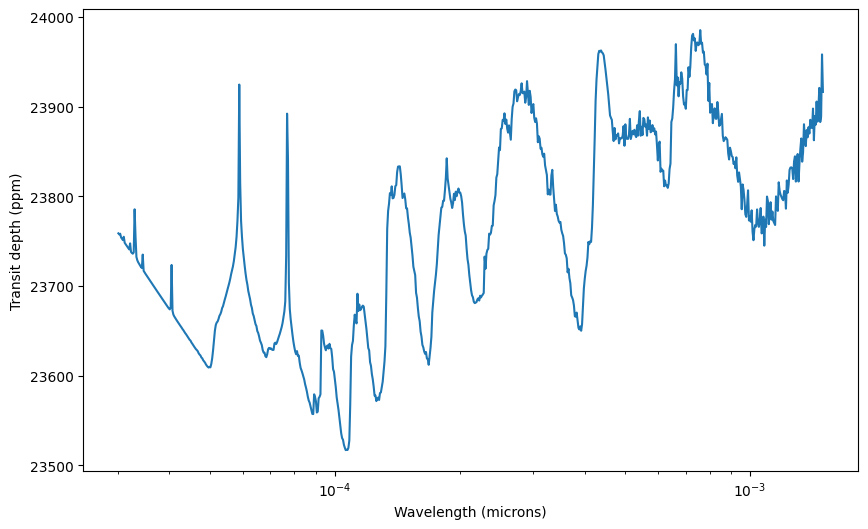

In [ ]:
planet_radius = 1.5*cst.r_jup
stellar_radius = cst.r_sun

wavelengths, transit_radii, _ = atmosphere.calculate_transit_radii(
        temperatures=temperatures,
        mass_fractions=mass_fractions,
        mean_molar_masses=mean_molar_masses,
        reference_gravity=gravity,
        planet_radius=planet_radius, # reference radius
        reference_pressure=0.01 # reference pressure in bar
)

# Get the transit depth
transit_depth = (transit_radii/stellar_radius)**2.

plt.plot(wavelengths, transit_depth*1e6)

plt.xscale('log')
plt.xlabel('Wavelength (microns)')
plt.ylabel(r'Transit depth (ppm)')
plt.show()

Now, lets add some clouds. pRT allows users to chose between many different cloud implementations which are described on the [documentation website](https://petitradtrans.readthedocs.io/en/latest/content/notebooks/including_clouds.html). Here we will just look at what happens if you specify a cloud (top) pressure. What pRT then does is to assume that the atmosphere is fully opaque at pressures larger than the specified cloud pressure. Since larger pressures mean lower altitudes this means that the atmosphere is fully opaque below a certain altitude.

### Exercise 4:
When calculating the transmission spectrum with `calculate_transit_radii()`, hand the function a keyword argument called `opaque_cloud_top_pressure`, which defines the cloud top pressure in bar. How does the spectrum compare to the cloud-free one if you set `opaque_cloud_top_pressure = 0.01`? Why does it look different? [You can click here to see if your solution is correct](https://www2.mpia-hd.mpg.de/~molliere/SSW/solutions_notebook_1.html#Exercise-4:).

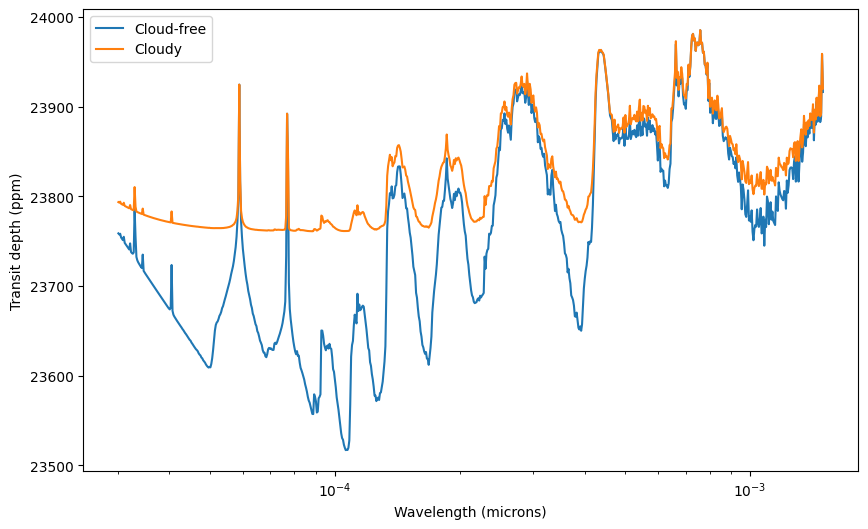

In [ ]:
wavelengths, transit_radii, _ = atmosphere.calculate_transit_radii(
        temperatures=temperatures,
        mass_fractions=mass_fractions,
        mean_molar_masses=mean_molar_masses,
        reference_gravity=gravity,
        planet_radius=planet_radius, # reference radius
        reference_pressure=0.01, # reference pressure in bar,
        opaque_cloud_top_pressure = 0.01 # ... # fill in!
)

# Get the transit depth
transit_depth_cloudy = (transit_radii/stellar_radius)**2.

# Plot the results
plt.plot(wavelengths, transit_depth*1e6, label = 'Cloud-free')
plt.plot(wavelengths, transit_depth_cloudy*1e6, label = 'Cloudy')

plt.xscale('log')
plt.xlabel('Wavelength (microns)')
plt.ylabel(r'Transit depth (ppm)')
plt.legend()
plt.show()

### Exercise 5:
Below we calculate and plot two transmission spectra: the first is identical to the cloudy spectrum above. For the second, we apply the following changes:
- We increase the mass fraction of all atmospheric species (except for H$_2$ and He) by a factor 10.
- We decrease the cloud deck pressure by a factor of 10.
- We divide the reference pressure by 9.4 (so almost a factor of 10).

How do the spectra compare? What do you think is happening? Imagine you were to retrieve the absorber mass fractions and cloud deck pressure from observations over a narrow wavelength range (e.g., 1.1 to 1.6 µm): would this be possible? Note that the 1.1 to 1.6 µm region corresponds to the wavelength range of the often-used WFC3 instrument of the Hubble Space Telescope. [You can click here to see if your solution is correct](https://www2.mpia-hd.mpg.de/~molliere/SSW/solutions_notebook_1.html#Exercise-5:).

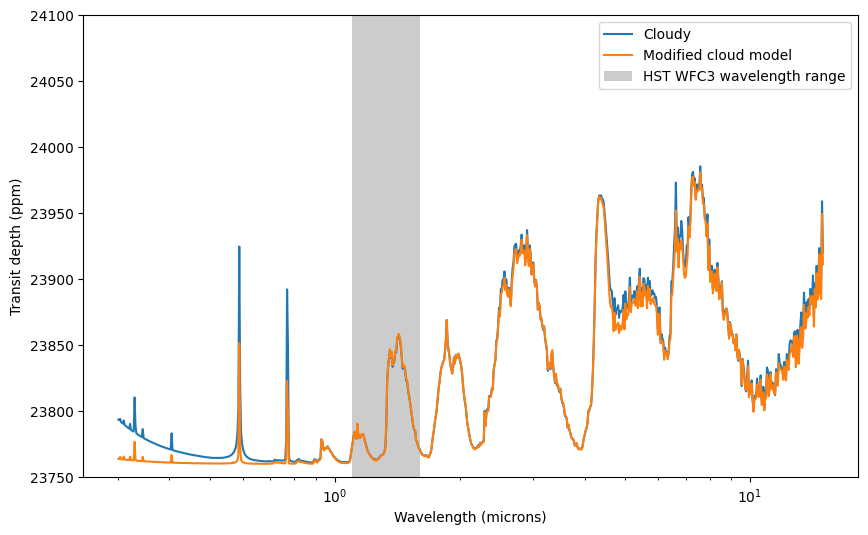

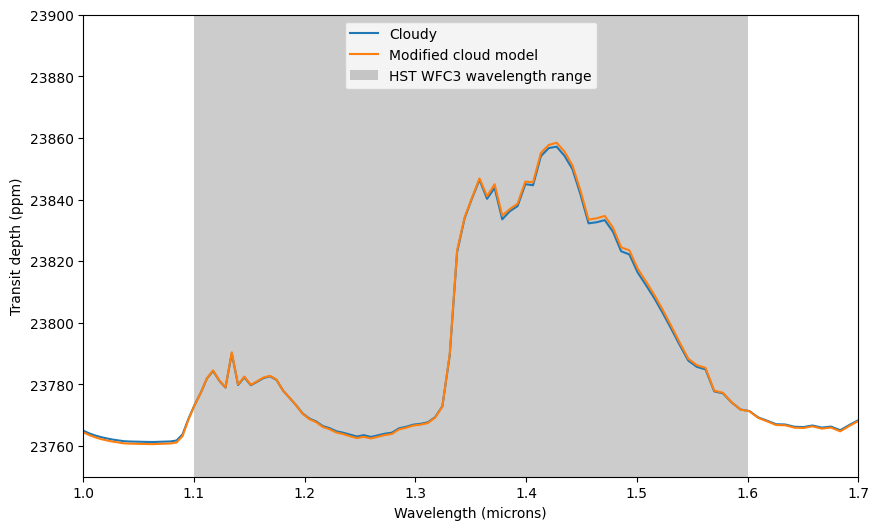

In [ ]:
mass_fraction_more_metals = mass_fractions.copy()
for name in mass_fraction_more_metals.keys():
    if name not in ['H2', 'He']:
        mass_fraction_more_metals[name] = 10. * mass_fraction_more_metals[name]

wavelengths, transit_radii, _ = atmosphere.calculate_transit_radii(
        temperatures=temperatures,
        mass_fractions=mass_fraction_more_metals,
        mean_molar_masses=mean_molar_masses,
        reference_gravity=gravity,
        planet_radius=planet_radius, # reference radius
        reference_pressure=0.01/9.4, # reference pressure in bar,
        opaque_cloud_top_pressure = 0.001 # ... # fill in!
)

transit_depth_cloudier = (transit_radii/stellar_radius)**2.

plt.plot(wavelengths*1e4, transit_depth_cloudy*1e6, label = 'Cloudy')
plt.plot(wavelengths*1e4, transit_depth_cloudier*1e6, label = 'Modified cloud model')

plt.fill_between(np.linspace(1.1, 1.6, 2), 23750, y2=24100, color = 'gray',
                 label = 'HST WFC3 wavelength range', alpha = 0.4, edgecolor = None)
plt.ylim([23750, 24100])

plt.xscale('log')
plt.xlabel('Wavelength (microns)')
plt.ylabel(r'Transit depth (ppm)')
plt.legend()
plt.show()

plt.plot(wavelengths*1e4, transit_depth_cloudy*1e6, label = 'Cloudy')
plt.plot(wavelengths*1e4, transit_depth_cloudier*1e6, label = 'Modified cloud model')

plt.fill_between(np.linspace(1.1, 1.6, 2), 23750, y2=24100, color = 'gray',
                 label = 'HST WFC3 wavelength range', alpha = 0.4, edgecolor = None)
plt.xlim([1.0,1.7])
plt.ylim([23750, 23900])

plt.xlabel('Wavelength (microns)')
plt.ylabel(r'Transit depth (ppm)')
plt.legend()
plt.show()